# The Macro-Announcement-Day Premium — a quantitative teardown 🔬
### Pooled Welch *t* + a same-density random-calendar placebo · per-type and per-decade splits · the TLT check · costs × turnover on the A-day overlay · the ex-FOMC third axis · a 100-seed synthetic null/power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![All_just_FOMC%3F: Confirmed](https://img.shields.io/badge/All_just_FOMC%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Savor & Wilson (2013, JFQA) report ~11.4 bps on scheduled macro-announcement days vs ~1.1 bps otherwise (1958-2009). We retry the **pooled** claim — CPI + NFP + FOMC — on the modern tradable tape with an actual, source-documented release calendar.

> ⚠️ **Data note.** SPY + TLT total-return closes (yfinance), 1997-01 → 2026-06; hardcoded calendar of 236 FOMC + 353 CPI + 353 NFP actual release dates (BLS archive index cross-checked against the official `histreleasedates.pdf`; construction in [`data.py`](../macro_announcement_premium/data.py)). SPY/TLT are survivorship-clean index vehicles. Numbers in [`docs/results.md`](../docs/results.md) (fingerprint `e42015f7ee3e`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.
>
> **Dedup map:** this is the *pooled* macro-day claim. The FOMC-only corner is [517-pre-fomc-drift](../../517-pre-fomc-drift/README.md) / [67-fed-drift](../../67-fed-drift/README.md); the cycle-week pattern is [135-fomc-cycle](../../135-fomc-cycle/README.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from macro_announcement_premium import data, strategy as st

START, ASOF = "1997-01-01", "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    PX = PX[(PX.index >= "1996-12-01") & (PX.index <= ASOF)]
    RET = st.daily_returns(PX["SPY"].dropna())
    RET = RET[RET.index >= START]
    MASKS = data.announcement_masks(RET.index)
else:
    PX = RET = MASKS = None
print("real cache present:", HAVE_REAL,
      "| daily returns:", (0 if RET is None else len(RET)),
      "| A-days:", (0 if MASKS is None else int(MASKS["ANY"].sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'years': 29.5, 'n_days': 7419, 'n_fomc': 236, 'n_cpi': 353, 'n_nfp': 353, 'n_adays': 923, 'frac_days': 12.4, 'n_overlap': 19, 'n_mapped': 10, 'a_mean_bps': 10.63, 'rest_mean_bps': 3.69, 'diff_bps': 6.94, 'welch_t': 1.57, 'a_t0': 2.55, 'share_return': 32.1, 'p_placebo': 0.0563, 'types': [('FOMC', 236, 22.2, 18.52, 2.25), ('CPI', 353, 4.55, 0.87, 0.12), ('NFP', 353, 13.24, 9.56, 1.38)], 'decades': [('1997-2006', 13.92, 2.46, 11.46, 1.51, 315), ('2007-2016', 14.05, 2.01, 12.04, 1.56, 312), ('2017-2026', 3.53, 6.75, -3.22, -0.42, 296)], 'tlt': {'a': -0.56, 'rest': 2.18, 'diff': -2.74, 't': -0.68, 'n': 749, 'days': 6016}, 'overlay': [(1.0, 10.63, 8.63, 2.07, 2.48, 10.05), (2.0, 10.63, 6.63, 1.59, 1.84, 10.05), (5.0, 10.63, 0.63, 0.15, -0.05, 10.05)], 'exfomc': {'mean': 6.65, 'diff': 2.97, 't': 0.58, 'n': 687, 'p': 0.3175}, 'fomc_leg': {'mean': 22.2, 'diff': 18.52, 't': 2.25, 'n': 236}, 'fomc_decades': [('1997-2006', 14.28, 1.21, 80), ('2007-2016', 45.29, 2.9, 80), ('2017-2026', -6.09, -0.41, 76)], 'syn': [(0.0, 0.45, 0.1, 4), (20.0, 20.45, 4.72, 100)], 'fingerprint': 'e42015f7ee3e'}


real cache present: True | daily returns: 7419 | A-days: 923


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pooled A-day premium **+6.94 bps/day** at Welch **t = 1.57**, placebo **p = 0.0563** — sub-bar. Only the FOMC leg clears (t = 2.25); CPI t = 0.12, NFP t = 1.38; 2017-2026 diff **-3.22** bps/day. |
| **Tradability** | `MIRAGE` | A-days-only overlay nets **+2.48%/yr at 1 bp** vs **10.05%** buy & hold; **-0.05%/yr at 5 bps**. 1-bp net t₀ = 2.07 is the best case and still forfeits ~3/4 of the market return. |
| **All just FOMC?** | `CONFIRMED` | Ex-FOMC A-days: **+2.97 bps/day**, t = **0.58**, placebo p = 0.3175 — a statistical zero vs the FOMC leg's +18.52 bps/day (t = 2.25). |

> 💡 In plain words: the announcement-day premium shows its silhouette, but on the modern tape it never clears the bar, it's all Fed days, it faded in 2017, and the trade version loses to doing nothing.

## 1 · The claim, steelmanned

Let $a_t\in\{0,1\}$ tag scheduled announcement sessions (CPI, NFP or FOMC — the union), all knowable ex-ante from published schedules. Let $r_t$ be SPY's total-return close-to-close daily return. Savor-Wilson:

$$\mathbb{E}[r_t\,|\,a_t=1]\;\gg\;\mathbb{E}[r_t\,|\,a_t=0],$$

with the announcement-day mean carrying *most* of the unconditional equity premium — compensation for bearing concentrated macro-news risk (Ai-Bansal give the preference foundations).

- **H₁ (pooled premium).** The A-minus-rest gap is positive and clears Welch t ≥ 2.
- **H₂ (breadth).** The premium is spread across CPI/NFP/FOMC — not one event type.
- **H₃ (deployability).** An A-days-only overlay survives costs and competes with buy & hold.

We find **H₁ rejected at the bar** (t = 1.57, p = 0.056), **H₂ rejected** (only FOMC clears; ex-FOMC t = 0.58), **H₃ rejected** (loses to buy & hold at every cost level).

## 2 · So what? — the honesty rails

- **Welch t** for the group split: A-days are meaningfully more volatile, so the unequal-variance statistic is the right one; daily close-to-close returns carry negligible serial correlation at this horizon (the placebo is the sharper null anyway).
- **Random-calendar placebo:** keep the *count* of A-days (923), relocate them uniformly, 20,000 draws — the exact answer to "could any same-density calendar look this special?".
- **One execution lag, documented:** the schedule is public in advance → enter the close *before* the A-day, exit the A-day close. One round trip per A-day, one-way costs × NAV on both legs, long-only, no borrow. Raw total-return arithmetic (no T-bill credit on idle cash — an omission that penalises the overlay, never flatters it).
- **Holiday releases** map to the next session (10 cases); 19 sessions carry two announcement types and count once in the union.

## 3 · How we'd know — the protocol

- **Tape.** SPY daily total-return closes, 1997-01-02 → 2026-06-30 (7,419 returns, 29.5 yrs); TLT from 2002-08.
- **Calendar.** 236 FOMC decision days (Fed historical calendars, scheduled only) + 353 CPI + 353 NFP actual release dates (BLS archive index, cross-checked 19/19 against `histreleasedates.pdf`; shutdown gaps kept as-is). **923** distinct A-sessions = 12.4% of days.
- **Primary test.** Pooled A-vs-rest Welch t + 20,000-draw placebo.
- **Splits.** Per type (each vs pure non-A days) and per decade.
- **Overlay.** Prior-close entry / A-day-close exit, 1 / 2 / 5 bps one-way.
- **Third axis.** The pooled test with FOMC sessions removed.
- **Control.** Synthetic worlds with a planted A-day edge, **100 seeds** (desk rule: ≥ 20): the null must not light up, the planted edge must.

## 4 · The teardown

### 4a · The pooled premium and its placebo

The observed A-minus-rest gap against 20,000 same-density random calendars. (The notebook redraws 4,000 for the chart; the canonical p uses the full 20,000 — quoted from `docs/results.md`.)

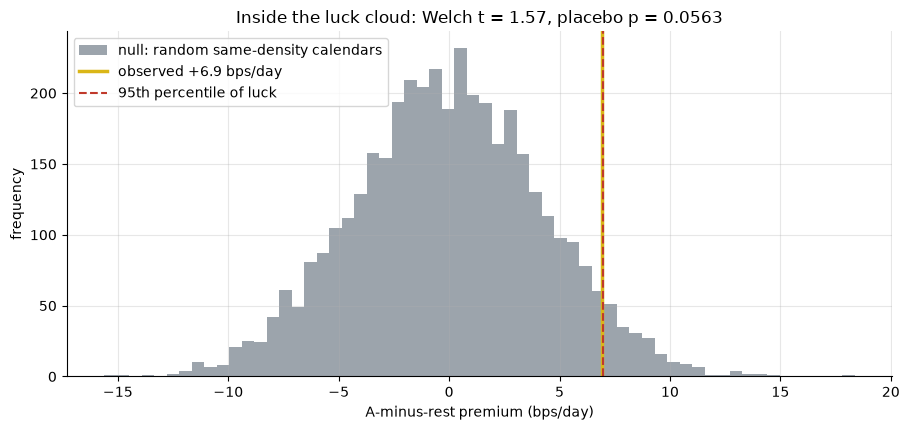

observed +6.94 bps/day  Welch t=1.57  canonical placebo p=0.0563 (20,000 draws)


In [2]:
if HAVE_REAL:
    pl = st.placebo_pvalue(RET.values, MASKS['ANY'], n_draws=4000)
    draws = pl['draws']*1e4; obs = pl['obs']*1e4
else:
    rng = np.random.default_rng(602); draws = rng.normal(0.0, 4.4, 4000); obs = R['diff_bps']
pv, wt = R['p_placebo'], R['welch_t']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: random same-density calendars')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'observed {obs:+.1f} bps/day')
ax.axvline(np.quantile(draws, 0.95), c=RED, ls='--', lw=1.5, label='95th percentile of luck')
ax.set_xlabel('A-minus-rest premium (bps/day)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: Welch t = {wt:.2f}, placebo p = {pv:.4f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} bps/day  Welch t={wt:.2f}  canonical placebo p={pv:.4f} (20,000 draws)')

> 💡 In plain words: the amber line sits at the **edge** of the luck cloud, not outside it — 5.6% of random calendars beat the observed **+6.94 bps/day**, and Welch *t* = 1.57 < 2. Under the house law (*REAL is earned by the tape*), a sub-2 *t* with three decades of published support reads **WEAK** — "the literature says real; this tape alone can't certify it."

### 4b · Per-type split — where does the premium live?

Each announcement type against the **pure non-announcement baseline** (6,496 days carrying no release of any type).

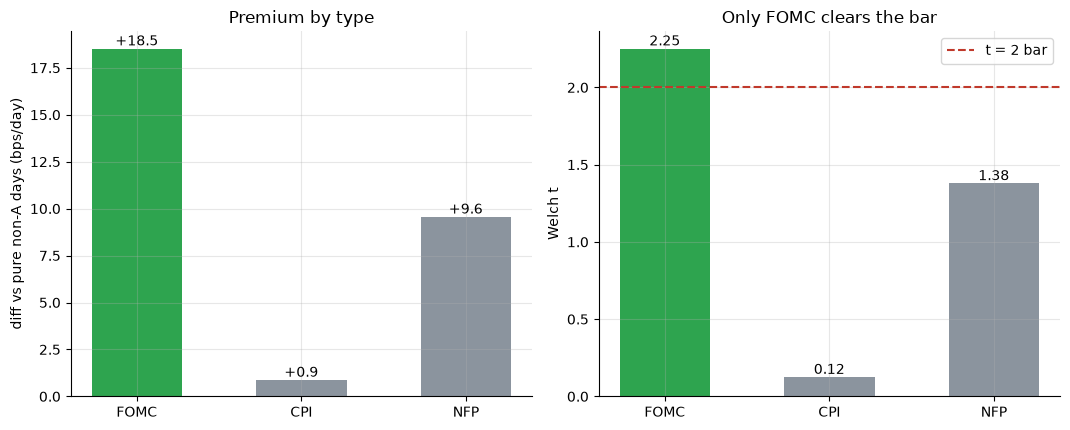

FOMC  n=236  mean  +22.20  diff  +18.52 bps/day  Welch t=+2.25
CPI   n=353  mean   +4.55  diff   +0.87 bps/day  Welch t=+0.12
NFP   n=353  mean  +13.24  diff   +9.56 bps/day  Welch t=+1.38


In [3]:
if HAVE_REAL:
    pure = ~MASKS['ANY']
    rows = [(nm, st.event_vs_rest(RET.values, MASKS[nm], base=pure)) for nm in ('FOMC','CPI','NFP')]
    tab = [(nm, s['n_ev'], s['ev_mean_bps'], s['diff_bps'], s['welch_t']) for nm, s in rows]
else:
    tab = R['types']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.4))
labels = [t[0] for t in tab]
a1.bar(labels, [t[3] for t in tab], color=[GREEN if t[4] >= 2 else GREY for t in tab], width=.55)
for i, t in enumerate(tab): a1.annotate(f'{t[3]:+.1f}', (i, max(t[3], 0)), ha='center', va='bottom')
a1.set_ylabel('diff vs pure non-A days (bps/day)'); a1.set_title('Premium by type')
a2.bar(labels, [t[4] for t in tab], color=[GREEN if t[4] >= 2 else GREY for t in tab], width=.55)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, t in enumerate(tab): a2.annotate(f'{t[4]:.2f}', (i, max(t[4], 0)), ha='center', va='bottom')
a2.set_ylabel('Welch t'); a2.set_title('Only FOMC clears the bar'); a2.legend()
plt.tight_layout(); plt.show()
for t in tab: print(f'{t[0]:<5} n={t[1]:>3}  mean {t[2]:+7.2f}  diff {t[3]:+7.2f} bps/day  Welch t={t[4]:+.2f}')

> 💡 In plain words: **FOMC days earn +18.5 bps over an ordinary day (t = 2.25)** — that's the entire effect. CPI days are indistinguishable from noise (t = 0.12); NFP days lean positive (t = 1.38) but don't clear. Savor-Wilson's breadth claim — macro news generally, not just the Fed — fails on this tape.

### 4c · Decades + the TLT check

Sub-period stability for the pooled premium, and the same calendar applied to long Treasuries (Savor-Wilson found announcement-day premia in bonds too).

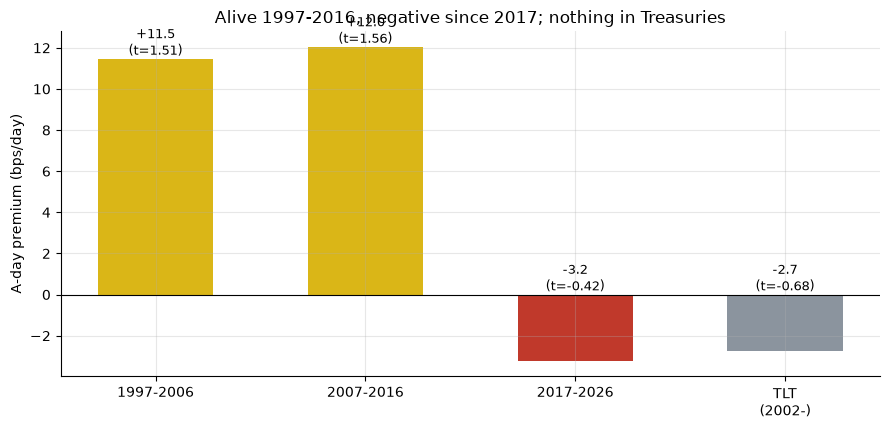

decades: [('1997-2006', '+11.46 bps (t=1.51)'), ('2007-2016', '+12.04 bps (t=1.56)'), ('2017-2026', '-3.22 bps (t=-0.42)')]
TLT: diff -2.74 bps/day (Welch t=-0.68)


In [4]:
if HAVE_REAL:
    splits = [('1997-2006','1997-01-01','2006-12-31'), ('2007-2016','2007-01-01','2016-12-31'),
              ('2017-2026','2017-01-01','2026-06-30')]
    dec = [(d['label'], d['diff_bps'], d['welch_t']) for d in st.subperiod_stats(RET, MASKS['ANY'], splits)]
    tlt_r = st.daily_returns(PX['TLT'].dropna()); tlt_r = tlt_r[tlt_r.index >= '2002-08-01']
    tm = data.announcement_masks(tlt_r.index)
    ts = st.event_vs_rest(tlt_r.values, tm['ANY'])
    tlt_diff, tlt_t = ts['diff_bps'], ts['welch_t']
else:
    dec = [(d[0], d[3], d[4]) for d in R['decades']]
    tlt_diff, tlt_t = R['tlt']['diff'], R['tlt']['t']
fig, ax = plt.subplots(figsize=(9.0, 4.4))
labels = [d[0] for d in dec] + ['TLT\n(2002-)']
vals = [d[1] for d in dec] + [tlt_diff]
tvals = [d[2] for d in dec] + [tlt_t]
ax.bar(labels, vals, color=[AMBER, AMBER, RED, GREY], width=.55)
for i, (v, t) in enumerate(zip(vals, tvals)):
    ax.annotate(f'{v:+.1f}\n(t={t:.2f})', (i, max(v, 0)), ha='center', va='bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('A-day premium (bps/day)')
ax.set_title('Alive 1997-2016, negative since 2017; nothing in Treasuries')
plt.tight_layout(); plt.show()
print('decades:', [(d[0], f'{d[1]:+.2f} bps (t={d[2]:.2f})') for d in dec])
print(f'TLT: diff {tlt_diff:+.2f} bps/day (Welch t={tlt_t:.2f})')

> 💡 In plain words: the pooled gap was ~+11-12 bps/day for two decades (each *t* ≈ 1.5, never individually decisive) and has been **-3.2 bps/day since 2017**. And the Treasury side of Savor-Wilson does not replicate on TLT (**-2.74 bps/day**, *t* = -0.68). No sub-period rescue, no cross-asset rescue.

### 4d · Costs — the A-days-only overlay

Enter the prior close, exit the A-day close, ~31 round trips/yr, 12.4% time in market. Gross/net labeled; raw total-return; no T-bill credit on cash (conservative).

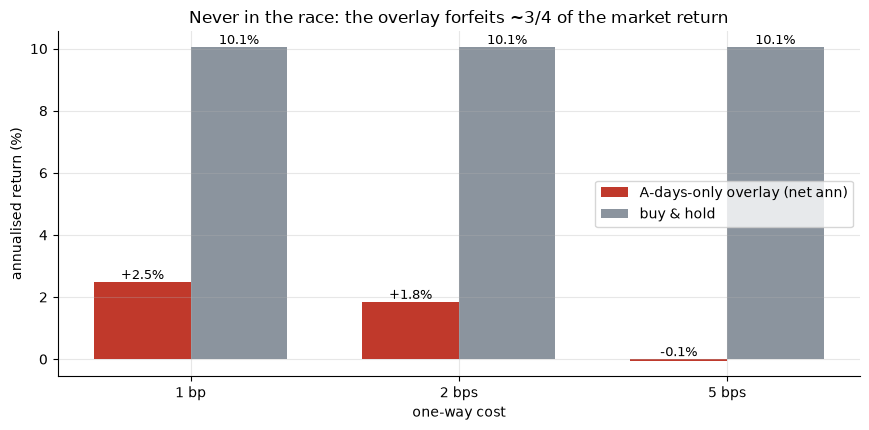

 1.0 bps/leg: gross +10.63 -> net +8.63 bps/A-day (net t0=+2.07) | net ann +2.48% vs B&H 10.05%
 2.0 bps/leg: gross +10.63 -> net +6.63 bps/A-day (net t0=+1.59) | net ann +1.84% vs B&H 10.05%
 5.0 bps/leg: gross +10.63 -> net +0.63 bps/A-day (net t0=+0.15) | net ann -0.05% vs B&H 10.05%


In [5]:
if HAVE_REAL:
    rows = [st.overlay_stats(RET, MASKS['ANY'], cost_bps=cb) for cb in (1.0, 2.0, 5.0)]
    tab = [(r['cost_bps'], r['gross_bps_per_aday'], r['net_bps_per_aday'], r['net_t0'],
            r['net_ann_pct'], r['bh_ann_pct']) for r in rows]
else:
    tab = R['overlay']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
x = np.arange(3)
ax.bar(x - .18, [t[4] for t in tab], .36, color=RED, label='A-days-only overlay (net ann)')
ax.bar(x + .18, [t[5] for t in tab], .36, color=GREY, label='buy & hold')
for i, t in enumerate(tab):
    ax.annotate(f'{t[4]:+.1f}%', (i - .18, max(t[4], 0)), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'{t[5]:.1f}%', (i + .18, t[5]), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['1 bp', '2 bps', '5 bps'])
ax.set_xlabel('one-way cost'); ax.set_ylabel('annualised return (%)')
ax.set_title('Never in the race: the overlay forfeits ~3/4 of the market return'); ax.legend()
plt.tight_layout(); plt.show()
for t in tab: print(f'{t[0]:>4.1f} bps/leg: gross {t[1]:+.2f} -> net {t[2]:+.2f} bps/A-day '
                    f'(net t0={t[3]:+.2f}) | net ann {t[4]:+.2f}% vs B&H {t[5]:.2f}%')

> 💡 In plain words: best case (1 bp/leg, institutional) the overlay nets **+2.48%/yr** — against **10.05%/yr** for holding SPY and doing nothing. At 5 bps the net A-day take is **+0.63 bps** (t₀ = 0.15): dead. **MIRAGE** — there is no deployable version of this calendar.

### 4e · Third axis — remove the FOMC sessions

The sharpest myth-check: is the *pooled* framing anything more than the FOMC-day premium the desk already tore down in [517](../../517-pre-fomc-drift/README.md) / [67](../../67-fed-drift/README.md)?

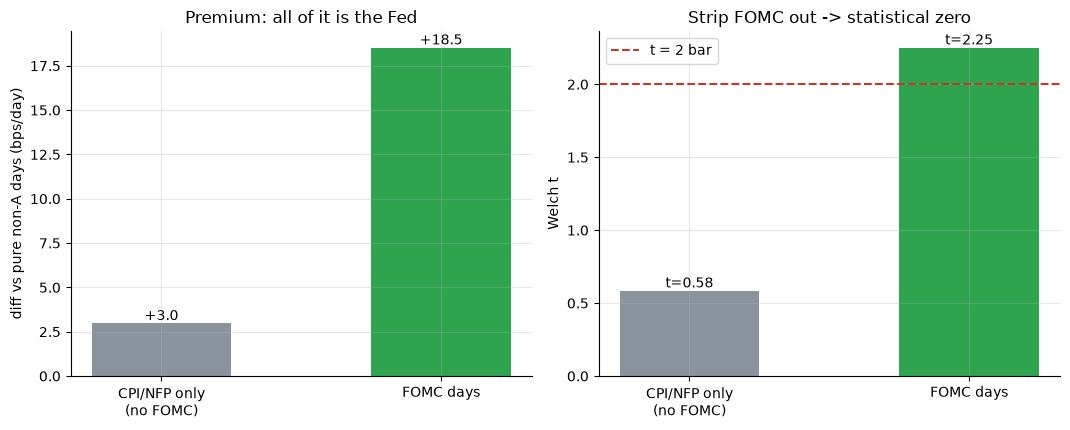

CPI/NFP only (no FOMC) diff   +2.97 bps/day  Welch t=+0.58
FOMC days              diff  +18.52 bps/day  Welch t=+2.25
FOMC engine by decade: [('1997-2006', '+14.3 bps (t=1.21)'), ('2007-2016', '+45.3 bps (t=2.90)'), ('2017-2026', '-6.1 bps (t=-0.41)')]


In [6]:
if HAVE_REAL:
    pure = ~MASKS['ANY']; exf = MASKS['ANY'] & ~MASKS['FOMC']
    s_ex = st.event_vs_rest(RET.values, exf, base=pure)
    s_fo = st.event_vs_rest(RET.values, MASKS['FOMC'], base=pure)
    pair = [('CPI/NFP only\n(no FOMC)', s_ex['diff_bps'], s_ex['welch_t']),
            ('FOMC days', s_fo['diff_bps'], s_fo['welch_t'])]
else:
    pair = [('CPI/NFP only\n(no FOMC)', R['exfomc']['diff'], R['exfomc']['t']),
            ('FOMC days', R['fomc_leg']['diff'], R['fomc_leg']['t'])]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.4))
a1.bar([p[0] for p in pair], [p[1] for p in pair], color=[GREY, GREEN], width=.5)
for i, p in enumerate(pair): a1.annotate(f'{p[1]:+.1f}', (i, max(p[1], 0)), ha='center', va='bottom')
a1.set_ylabel('diff vs pure non-A days (bps/day)'); a1.set_title('Premium: all of it is the Fed')
a2.bar([p[0] for p in pair], [p[2] for p in pair], color=[GREY, GREEN], width=.5)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, p in enumerate(pair): a2.annotate(f't={p[2]:.2f}', (i, max(p[2], 0)), ha='center', va='bottom')
a2.set_ylabel('Welch t'); a2.set_title('Strip FOMC out -> statistical zero'); a2.legend()
plt.tight_layout(); plt.show()
for p in pair: print(f'{p[0].replace(chr(10), " "):<22} diff {p[1]:+7.2f} bps/day  Welch t={p[2]:+.2f}')
print('FOMC engine by decade:', [(d[0], f'{d[1]:+.1f} bps (t={d[2]:.2f})') for d in R['fomc_decades']])

> 💡 In plain words: **CONFIRMED — it's all FOMC.** Ex-FOMC announcement days earn **+2.97 bps/day** over ordinary days (*t* = 0.58, placebo *p* = 0.3175); the FOMC leg carries **+18.52 bps/day** (*t* = 2.25). And even the FOMC engine is a 2007-2016 story (*t* = 2.90) that reads *t* = -0.41 since 2017 — consistent with the decayed pre-FOMC drift in study 517.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic daily worlds with a **planted** A-day edge, seed-averaged (the notebook runs 20 seeds for speed; the canonical 100-seed numbers are quoted from `docs/results.md`). The null must not light up; the planted edge must.

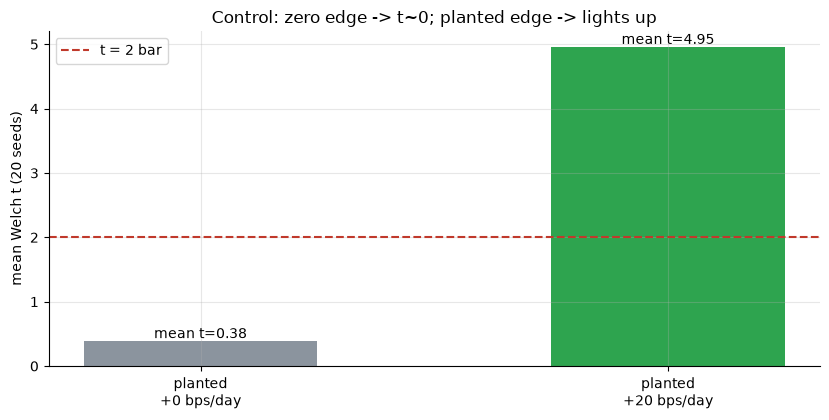

planted   +0.0 bps/day: mean diff   +1.68  mean t  +0.38
planted  +20.0 bps/day: mean diff  +21.68  mean t  +4.95
canonical (100 seeds): [(0.0, 'mean t=0.10, share |t|>=2: 4%'), (20.0, 'mean t=4.72, share |t|>=2: 100%')]


In [7]:
rows = []
for edge in (0.0, 0.0020):
    sw = st.synthetic_sweep(edge=edge, n_seeds=20)
    rows.append((sw['edge_bps'], sw['mean_diff_bps'], sw['mean_t']))
fig, ax = plt.subplots(figsize=(8.4, 4.3))
labels = [f'planted\n{r[0]:+.0f} bps/day' for r in rows]
ax.bar(labels, [r[2] for r in rows], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(rows): ax.annotate(f'mean t={r[2]:.2f}', (i, max(r[2], 0)), ha='center', va='bottom')
ax.set_ylabel('mean Welch t (20 seeds)')
ax.set_title('Control: zero edge -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for r in rows: print(f'planted {r[0]:+6.1f} bps/day: mean diff {r[1]:+7.2f}  mean t {r[2]:+6.2f}')
print('canonical (100 seeds):', [(s[0], f'mean t={s[2]:.2f}, share |t|>=2: {s[3]}%') for s in R['syn']])

> 💡 In plain words: with no planted premium the detector reads mean *t* = 0.10 and a 4% false-positive rate (nominal); a planted +20 bps/day edge is recovered at mean *t* = 4.72 in 100/100 seeds. The machinery is unbiased and well-powered — the real-tape *t* = 1.57 is a genuine sub-bar reading, not a power failure. *(A machinery proof only — never cited to support a stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — pooled A-day premium **+6.94 bps/day** at Welch **t = 1.57** (placebo p = 0.0563) on 29.5 years of SPY: below the t ≥ 2 bar. Only FOMC clears (t = 2.25); CPI/NFP carry nothing; the pooled effect reads -3.22 bps/day since 2017; TLT shows nothing. The literature (1958-2009) says real; this tape can't certify the pooled claim.
- **Tradability `MIRAGE`** — the A-days-only overlay nets +2.48%/yr at 1 bp vs 10.05% buy & hold and -0.05%/yr at 5 bps. Nothing deployable survives.
- **All just FOMC? `CONFIRMED`** — ex-FOMC t = 0.58 (placebo p = 0.32) vs FOMC t = 2.25. The pooled macro-announcement premium is the FOMC-day premium wearing a bigger calendar — and that engine faded after 2017.

## 6 · Going further

- **Sample matters.** Savor-Wilson end in 2009; the 2007-2016 window is where our FOMC leg peaks (t = 2.90). A result born in one regime and sold as a law of markets is the anomaly literature's oldest failure mode (McLean-Pontiff).
- **The beta channel is untested here.** Savor-Wilson's deeper claim — the *security market line steepens* on A-days — needs a cross-section, not one index; a beta-sorted panel on announcement days is the natural extension.
- **Intraday would sharpen it.** The FOMC statement lands at 14:00 ET; close-to-close dilutes the event window (study 517 splits overnight/intraday around the FOMC and finds the drift decayed there too).

*The reproducible core is offline and deterministic; the calendar is actual release dates, hardcoded and sourced in `data.py`. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*